In [2]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
from sklearn.preprocessing import MultiLabelBinarizer

In [4]:
file_path = 'df_labeled_all_final_25.csv'
df = pd.read_csv(file_path, on_bad_lines='warn')

In [5]:
df.head(5)

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,method,motive,location,prison_term,many_victims,year,season,attempt,victim_child_or_helpless,cruel,region_name
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,тяжелые предметы,личная неприязнь,"рабочая зона, уличное пространство",9.000000,0,1998,Лето,0,0,0,Омская область
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,холодное оружие,личная неприязнь,"общественное место, уличное пространство",7.986857,0,1999,Зима,0,0,0,Еврейская автономная область
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,"физическое воздействие, холодное оружие","корысть, личная неприязнь",жилое помещение,13.000000,1,2000,Лето,1,0,0,Кемеровская область
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,огнестрельное оружие,"корысть, личная неприязнь",уличное пространство,13.000000,0,2005,Лето,0,0,0,Республика Бурятия
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,удушение,личная неприязнь,жилое помещение,8.311355,1,2009,Весна,0,0,0,Иркутская область


In [6]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [38]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    25571
1    11998
Name: count, dtype: int64

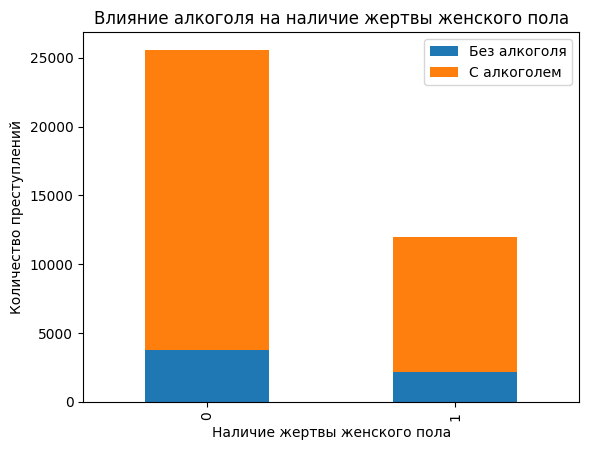

In [45]:
cross_tab = pd.crosstab(df['has_woman_victim'], df['alcohol'])
cross_tab.plot(kind='bar', stacked=True)
plt.title('Влияние алкоголя на наличие жертвы женского пола')
plt.xlabel('Наличие жертвы женского пола')
plt.ylabel('Количество преступлений')
plt.legend(['Без алкоголя', 'С алкоголем'])
plt.show()

Text(0, 0.5, 'Срок заключения')

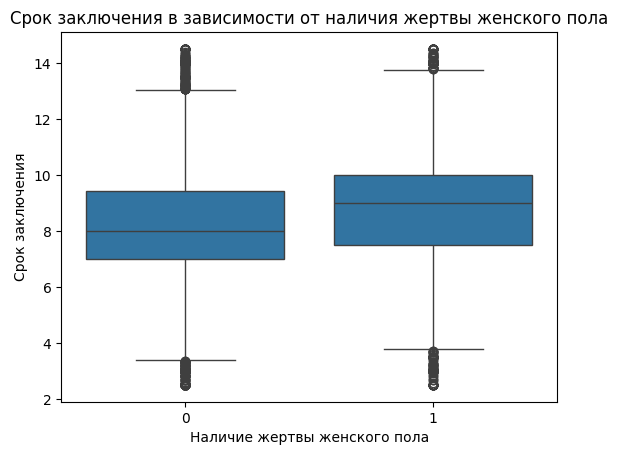

In [52]:
Q1 = df['prison_term'].quantile(0.25)
Q3 = df['prison_term'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['prison_term'] >= lower_bound) & (df['prison_term'] <= upper_bound)]


sns.boxplot(x='has_woman_victim', y='prison_term', data=df_filtered)
plt.title('Срок заключения в зависимости от наличия жертвы женского пола')
plt.xlabel('Наличие жертвы женского пола')
plt.ylabel('Срок заключения')

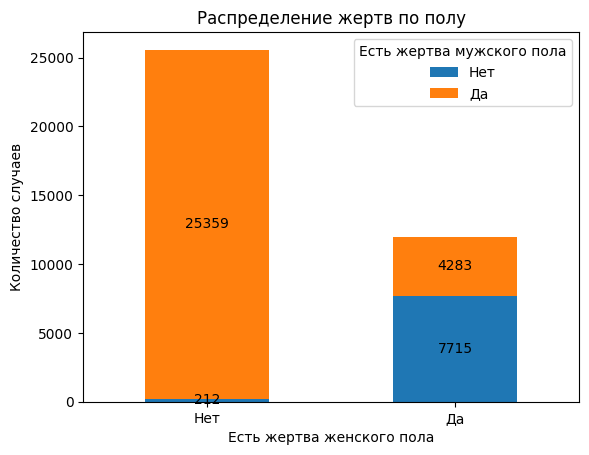

In [67]:
cross_tab = pd.crosstab(df['has_woman_victim'], df['has_man_victim'])
ax = cross_tab.plot(kind='bar', stacked=True)

plt.title('Распределение жертв по полу')
plt.xlabel('Есть жертва женского пола')
plt.ylabel('Количество случаев')
plt.xticks([0, 1], ['Нет', 'Да'], rotation=0)
plt.legend(title='Есть жертва мужского пола', labels=['Нет', 'Да'])

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                   (p.get_x() + width/2, p.get_y() + height/2),
                   ha='center', va='center')

plt.show()

In [83]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    25571
1    11998
Name: count, dtype: int64

In [84]:
df['has_man_victim'].value_counts()

has_man_victim
1    29642
0     7927
Name: count, dtype: int64

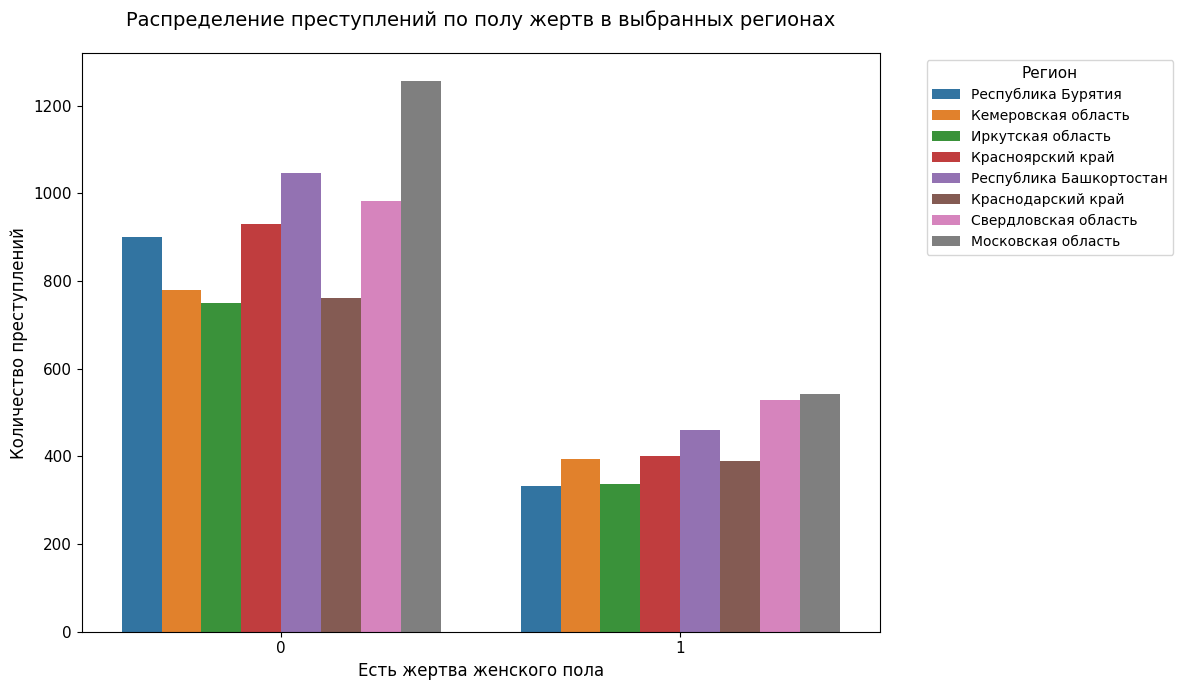

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

target_regions = [
    'Московская область', 
    'Свердловская область',
    'Республика Башкортостан',
    'Красноярский край',
    'Республика Бурятия',
    'Кемеровская область',
    'Краснодарский край',
    'Иркутская область'
]

df_filtered = df[df['region_name'].isin(target_regions)]

plt.figure(figsize=(12, 7))
sns.countplot(
    data=df_filtered,
    x='has_woman_victim',
    hue='region_name'
)

plt.title('Распределение преступлений по полу жертв в выбранных регионах', fontsize=14, pad=20)
plt.xlabel('Есть жертва женского пола', fontsize=12)
plt.ylabel('Количество преступлений', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title='Регион',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

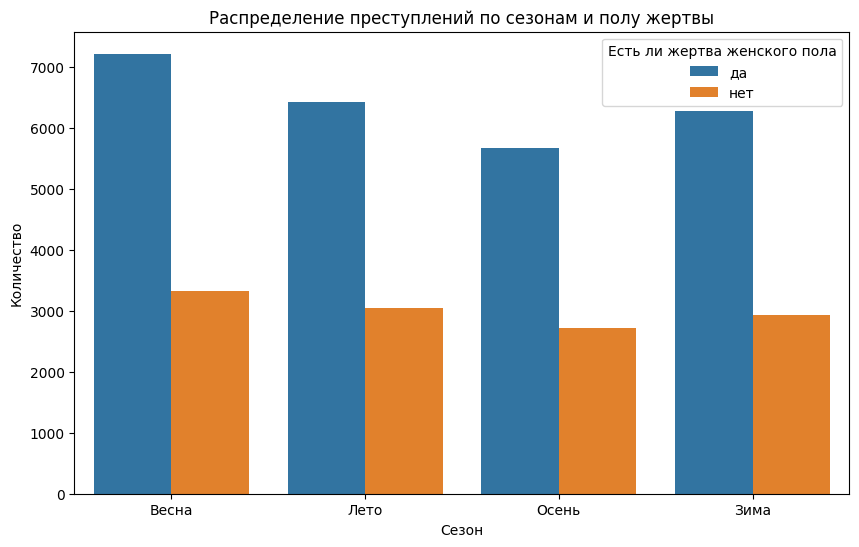

In [74]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', hue='has_woman_victim', 
             order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение преступлений по сезонам и полу жертвы')
plt.xlabel('Сезон')
plt.ylabel('Количество')
plt.legend(title='Есть ли жертва женского пола', labels=['да', 'нет'])
plt.show()

Text(95.72222222222221, 0.5, 'Наличие жертвы женского пола')

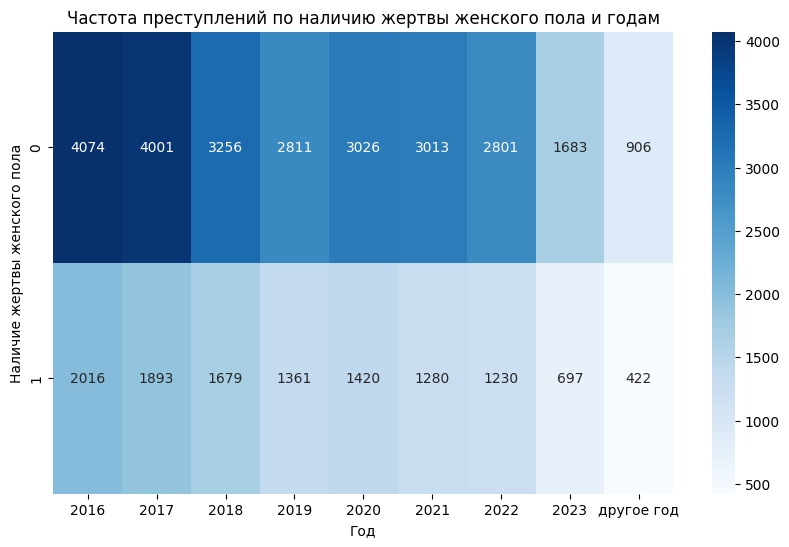

In [58]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

contingency_table = pd.crosstab(df['has_woman_victim'], df['year'])


plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
plt.title('Частота преступлений по наличию жертвы женского пола и годам')
plt.xlabel('Год')
plt.ylabel('Наличие жертвы женского пола')

ОБРАБАТЫВАЕМ ПРИЗНАКИ

In [7]:
df['method'].value_counts()

method
холодное оружие                                                                              18570
физическое воздействие, холодное оружие                                                       8639
физическое воздействие                                                                        1993
огнестрельное оружие                                                                          1803
тяжелые предметы, физическое воздействие                                                      1498
удушение, физическое воздействие                                                              1214
другое                                                                                        1058
тяжелые предметы                                                                               699
удушение                                                                                       688
тяжелые предметы, физическое воздействие, холодное оружие                                      382
тяж

In [8]:
df['motive'].value_counts()

motive
личная неприязнь                                        34688
корысть, личная неприязнь                                 935
корысть                                                   610
другое                                                    468
личная неприязнь, ревность                                310
                                                        ...  
личная неприязнь, аморальность поведения потерпевшей        1
конфликт, личная неприязнь                                  1
ревность, корысть                                           1
национальная ненависть                                      1
аморальность, противоправность                              1
Name: count, Length: 117, dtype: int64

In [9]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        27891
уличное пространство                                                                                                                    4430
жилое помещение, уличное пространство                                                                                                   1545
другое                                                                                                                                  1225
жилое помещение, подъезд и прилегающие зоны                                                                                              489
общественное место                                                                                                                       408
подъезд и прилегающие зоны                                                                                                               394
обще

In [10]:
def replace_drugoe(value):
    if pd.isna(value): 
        return value
    parts = value.split(", ") if ", " in value else [value]
    parts = ["другое место" if part == "другое" else part for part in parts]
    return ", ".join(parts)

df['location'] = df['location'].apply(replace_drugoe)

In [ ]:
# valid_locations = [
#     "жилое помещение", "уличное пространство", "общественный транспорт",
#     "общественное место", "подъезд и прилегающие зоны", "рабочая зона", "другое место"
# ]
# valid_methods = [
#     "физическое воздействие", "холодное оружие", "тяжелые предметы",
#     "огнестрельное оружие", "удушение", "другое"
# ]

# for loc in valid_locations:
#     df[loc] = (df['location'] == loc).astype(int)

# for method in valid_methods:
#     df[method] = (df['method'] == method).astype(int)

# # df = df.drop(['location', 'method'], axis=1)

In [11]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'другой мотив',
    'сострадание': 'другой мотив',
    'страх': 'другой мотив',
    'жалость': 'другой мотив',
    'самозащита': 'другой мотив',
    'защита': 'другой мотив',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'другой мотив'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
другой мотив                              510
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
аморальность, личная неприязнь             16
месть                                      12
аморальность                               12
корысть, месть                              7
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, личная неприязнь, месть            3
другой мотив, личная неприязнь              3
личная неприязнь, месть, ревность           3
корысть, ревность                           1
аморальность, месть                         1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [ ]:
# valid_motive = [
#     "личная неприязнь", "ревность", "корысть",
#     "алкоголь/наркотики", "аморальность", "насилие", "другой мотив"
# ]
# for motive in valid_motive:
#     df[motive] = (df['motive'] == motive).astype(int)

In [12]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,method,motive,location,prison_term,many_victims,year,season,attempt,victim_child_or_helpless,cruel,region_name
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,тяжелые предметы,личная неприязнь,"рабочая зона, уличное пространство",9.000000,0,1998,Лето,0,0,0,Омская область
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,холодное оружие,личная неприязнь,"общественное место, уличное пространство",7.986857,0,1999,Зима,0,0,0,Еврейская автономная область
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,"физическое воздействие, холодное оружие","корысть, личная неприязнь",жилое помещение,13.000000,1,2000,Лето,1,0,0,Кемеровская область
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,огнестрельное оружие,"корысть, личная неприязнь",уличное пространство,13.000000,0,2005,Лето,0,0,0,Республика Бурятия
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,удушение,личная неприязнь,жилое помещение,8.311355,1,2009,Весна,0,0,0,Иркутская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,Кривцанова Галина Петровна,Вынесен ПРИГОВОР,1,0,1,1,0,1,холодное оружие,личная неприязнь,жилое помещение,9.000000,0,2016,Лето,0,0,0,Ставропольский край
37565,62712,Егоров Андрей Владимирович,Вынесен ПРИГОВОР,1,0,1,1,1,0,холодное оружие,"личная неприязнь, ревность",жилое помещение,9.000000,0,2018,Весна,0,0,0,Нижегородская область
37566,54534,Семенов Олег Владимирович,Вынесен ПРИГОВОР,1,0,1,0,1,1,"физическое воздействие, холодное оружие",ревность,жилое помещение,3.830000,0,2018,Осень,1,0,0,Республика Татарстан
37567,47517,Ладин Александр Максимович,Вынесен ПРИГОВОР,1,0,1,1,1,1,"физическое воздействие, холодное оружие",личная неприязнь,жилое помещение,21.000000,1,2017,Осень,0,0,0,Свердловская область


In [13]:
mlb = MultiLabelBinarizer()
multilabel_features = ['method', 'motive', 'location']

for col in multilabel_features:
    df[col] = df[col].str.split(", ")
    col_binarized = mlb.fit_transform(df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_)
    col_df.index = df.index
    df = pd.concat([df, col_df], axis=1).drop(col, axis=1)

# for feature in multilabel_features:
#     df[feature] = df[feature].apply(lambda x: ','.join(x) if isinstance(x, list) else x)

In [14]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,месть,насилие,ревность,другое место,жилое помещение,общественное место,общественный транспорт,подъезд и прилегающие зоны,рабочая зона,уличное пространство
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,9.000000,...,0,0,0,0,0,0,0,0,1,1
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,7.986857,...,0,0,0,0,0,1,0,0,0,1
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,13.000000,...,0,0,0,0,1,0,0,0,0,0
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,13.000000,...,0,0,0,0,0,0,0,0,0,1
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,8.311355,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,Кривцанова Галина Петровна,Вынесен ПРИГОВОР,1,0,1,1,0,1,9.000000,...,0,0,0,0,1,0,0,0,0,0
37565,62712,Егоров Андрей Владимирович,Вынесен ПРИГОВОР,1,0,1,1,1,0,9.000000,...,0,0,1,0,1,0,0,0,0,0
37566,54534,Семенов Олег Владимирович,Вынесен ПРИГОВОР,1,0,1,0,1,1,3.830000,...,0,0,1,0,1,0,0,0,0,0
37567,47517,Ладин Александр Максимович,Вынесен ПРИГОВОР,1,0,1,1,1,1,21.000000,...,0,0,0,0,1,0,0,0,0,0


ВЫПИШЕМ ВСЕ ПРИЗНАКИ

In [15]:
df.value_counts()

id      judge                        decision          gender_accused  prior_convictions  alcohol  precrime_argument  has_woman_victim  has_man_victim  prison_term  many_victims  year  season  attempt  victim_child_or_helpless  cruel  region_name              другое  огнестрельное оружие  тяжелые предметы  удушение  физическое воздействие  холодное оружие  алкоголь/наркотики  аморальность  другой мотив  корысть  личная неприязнь  месть  насилие  ревность  другое место  жилое помещение  общественное место  общественный транспорт  подъезд и прилегающие зоны  рабочая зона  уличное пространство
28      Неверов Е. Ю.                Вынесен ПРИГОВОР  1               0                  0        1                  1                 0               8.00         0             2016  Весна   0        0                         0      Республика Адыгея        0       0                     0                 1         1                       0                0                   0             0        

In [16]:
target = 'has_woman_victim'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name', 'season']
other_features = [
    'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
    'has_man_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',  
    'физическое воздействие', 'холодное оружие', 'тяжелые предметы',
    'огнестрельное оружие','удушение', 'другое',
    'личная неприязнь', 'ревность', 'корысть', 'алкоголь/наркотики',
    'аморальность', 'насилие', 'другой мотив', 
    'жилое помещение', 'уличное пространство', 'общественный транспорт',
    'общественное место', 'подъезд и прилегающие зоны', 'рабочая зона', 'другое место', 
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 35), (7514, 35), (7514, 35))

МОДЕЛЬ CatBoost

In [17]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


[I 2025-04-29 23:58:47,874] A new study created in memory with name: no-name-a7b25846-a0e6-4370-ad10-9f0ed82b2a0d
[I 2025-04-29 23:58:54,094] Trial 0 finished with value: 0.8846837823558675 and parameters: {'iterations': 473, 'learning_rate': 0.07027422922025779, 'depth': 10, 'l2_leaf_reg': 8.73188573544078, 'bagging_temperature': 0.5659590310050349}. Best is trial 0 with value: 0.8846837823558675.
[I 2025-04-29 23:59:03,512] Trial 1 finished with value: 0.884962998379219 and parameters: {'iterations': 680, 'learning_rate': 0.0476823215983697, 'depth': 10, 'l2_leaf_reg': 8.811655715484303, 'bagging_temperature': 0.35201332435667165}. Best is trial 1 with value: 0.884962998379219.
[I 2025-04-29 23:59:04,332] Trial 2 finished with value: 0.8825435057221331 and parameters: {'iterations': 146, 'learning_rate': 0.03688878870936775, 'depth': 5, 'l2_leaf_reg': 3.7164839974245707, 'bagging_temperature': 0.9452385895853553}. Best is trial 1 with value: 0.884962998379219.
[I 2025-04-29 23:59:07,

Best CatBoost Params:
{'iterations': 851, 'learning_rate': 0.07538244622810182, 'depth': 8, 'l2_leaf_reg': 6.552545485765109, 'bagging_temperature': 0.18951457738895638}
0:	learn: 0.6206282	total: 15.1ms	remaining: 12.9s
100:	learn: 0.2992332	total: 1.34s	remaining: 9.99s
200:	learn: 0.2854841	total: 2.77s	remaining: 8.95s
300:	learn: 0.2714549	total: 4.25s	remaining: 7.77s
400:	learn: 0.2590746	total: 5.72s	remaining: 6.42s
500:	learn: 0.2479795	total: 7.22s	remaining: 5.04s
600:	learn: 0.2376470	total: 8.72s	remaining: 3.63s
700:	learn: 0.2272160	total: 10.3s	remaining: 2.2s
800:	learn: 0.2173950	total: 11.8s	remaining: 736ms
850:	learn: 0.2133513	total: 12.5s	remaining: 0us

CatBoost Results:
Accuracy: 0.8832
Precision: 0.8911
Recall: 0.8832
F1: 0.8769

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      5115
           1       0.95      0.67      0.79      2399

    accuracy                           0.88   

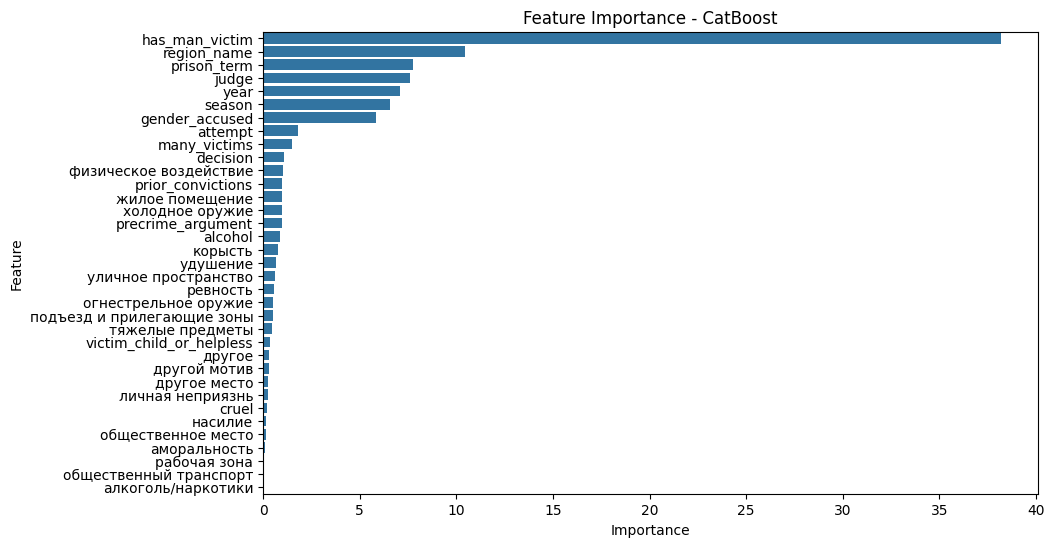

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [21]:
from joblib import dump

In [22]:
target = 'has_woman_victim'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name', 'season']
other_features = [
    'gender_accused', 
    'has_man_victim',
    'физическое воздействие'
]

features2 = categorical_features + other_features + numeric_features

X = df[features2]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 


((22541, 9), (7514, 9), (7514, 9))

[I 2025-04-30 00:14:51,589] A new study created in memory with name: no-name-2eb54d92-5b49-46d0-a6f6-0f09593e113f
[I 2025-04-30 00:14:53,340] Trial 0 finished with value: 0.8794182728044391 and parameters: {'iterations': 801, 'learning_rate': 0.09388834536434554, 'depth': 9, 'l2_leaf_reg': 1.9114795710066532, 'bagging_temperature': 0.07668736550281008}. Best is trial 0 with value: 0.8794182728044391.
[I 2025-04-30 00:14:54,939] Trial 1 finished with value: 0.8792650308045927 and parameters: {'iterations': 598, 'learning_rate': 0.2118274298561648, 'depth': 10, 'l2_leaf_reg': 7.77968508820314, 'bagging_temperature': 0.291666437975137}. Best is trial 0 with value: 0.8794182728044391.
[I 2025-04-30 00:14:56,240] Trial 2 finished with value: 0.8795233892526544 and parameters: {'iterations': 207, 'learning_rate': 0.06586749267116557, 'depth': 6, 'l2_leaf_reg': 1.3032570319833008, 'bagging_temperature': 0.15722452050697822}. Best is trial 2 with value: 0.8795233892526544.
[I 2025-04-30 00:15:

Best CatBoost Params:
{'iterations': 392, 'learning_rate': 0.2780196468762544, 'depth': 10, 'l2_leaf_reg': 6.765380910097995, 'bagging_temperature': 0.653922880456364}
0:	learn: 0.5048614	total: 5.71ms	remaining: 2.23s
100:	learn: 0.2371083	total: 1.91s	remaining: 5.51s
200:	learn: 0.1643291	total: 4.17s	remaining: 3.96s
300:	learn: 0.1190415	total: 6.52s	remaining: 1.97s
391:	learn: 0.0892041	total: 8.61s	remaining: 0us

CatBoost Results:
Accuracy: 0.8754
Precision: 0.8829
Recall: 0.8754
F1: 0.8685

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      5115
           1       0.94      0.65      0.77      2399

    accuracy                           0.88      7514
   macro avg       0.90      0.82      0.84      7514
weighted avg       0.88      0.88      0.87      7514


Feature Importance:
                  Feature  Importance
6          has_man_victim   22.938617
3             region_name   17.228822
4        

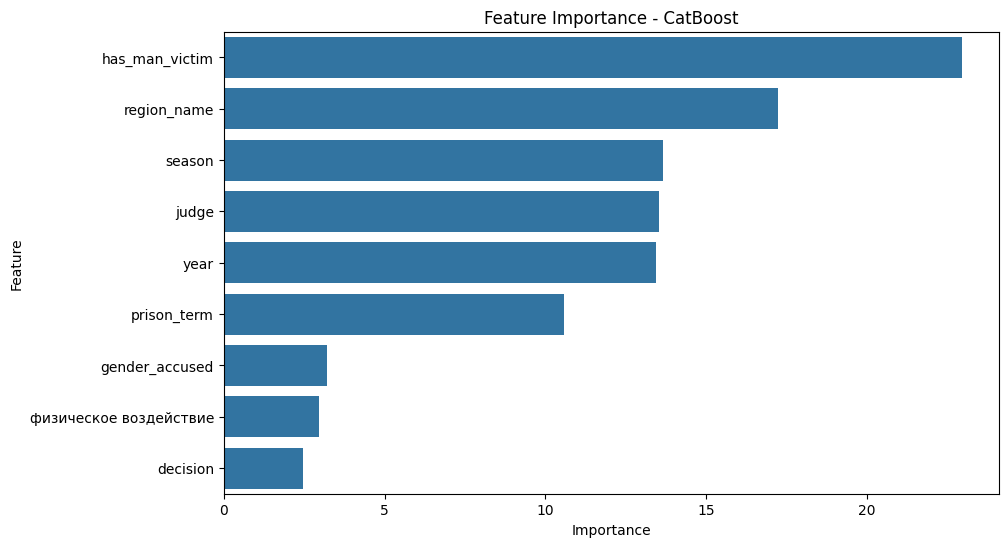

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features2, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [81]:
target = 'has_woman_victim'

numeric_features = ['prison_term']
categorical_features = ['year', 'season']
other_features = [
    'has_man_victim',
    'gender_accused', 
    'precrime_argument'
]

features2 = categorical_features + other_features + numeric_features

X = df[features2]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 


((22541, 6), (7514, 6), (7514, 6))

[I 2025-04-30 01:55:17,065] A new study created in memory with name: no-name-4d0bc7c4-60c4-44f1-80f7-0189aeef7937
[I 2025-04-30 01:55:19,944] Trial 0 finished with value: 0.8795233892526544 and parameters: {'iterations': 579, 'learning_rate': 0.011240044041323168, 'depth': 4, 'l2_leaf_reg': 7.888806902570065, 'bagging_temperature': 0.592169748357467}. Best is trial 0 with value: 0.8795233892526544.
[I 2025-04-30 01:55:22,991] Trial 1 finished with value: 0.8795233892526544 and parameters: {'iterations': 700, 'learning_rate': 0.011156987866244257, 'depth': 6, 'l2_leaf_reg': 6.85703415633864, 'bagging_temperature': 0.20060771913677622}. Best is trial 0 with value: 0.8795233892526544.
[I 2025-04-30 01:55:24,547] Trial 2 finished with value: 0.8795233892526544 and parameters: {'iterations': 287, 'learning_rate': 0.010694690497581467, 'depth': 5, 'l2_leaf_reg': 3.877844394108662, 'bagging_temperature': 0.2168990004629089}. Best is trial 0 with value: 0.8795233892526544.
[I 2025-04-30 01:55:

Best CatBoost Params:
{'iterations': 871, 'learning_rate': 0.17748369455096133, 'depth': 5, 'l2_leaf_reg': 7.114435836550333, 'bagging_temperature': 0.3998175753048995}
0:	learn: 0.5411326	total: 7.56ms	remaining: 6.58s
100:	learn: 0.3191337	total: 576ms	remaining: 4.39s
200:	learn: 0.3144198	total: 1.19s	remaining: 3.95s
300:	learn: 0.3113148	total: 1.79s	remaining: 3.39s
400:	learn: 0.3081793	total: 2.4s	remaining: 2.81s
500:	learn: 0.3052818	total: 3s	remaining: 2.22s
600:	learn: 0.3024675	total: 3.64s	remaining: 1.64s
700:	learn: 0.2997422	total: 4.25s	remaining: 1.03s
800:	learn: 0.2979303	total: 4.86s	remaining: 425ms
870:	learn: 0.2963623	total: 5.29s	remaining: 0us

CatBoost Results:
Accuracy: 0.8800
Precision: 0.8920
Recall: 0.8800
F1: 0.8723

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      5115
           1       0.97      0.64      0.77      2399

    accuracy                           0.88      7

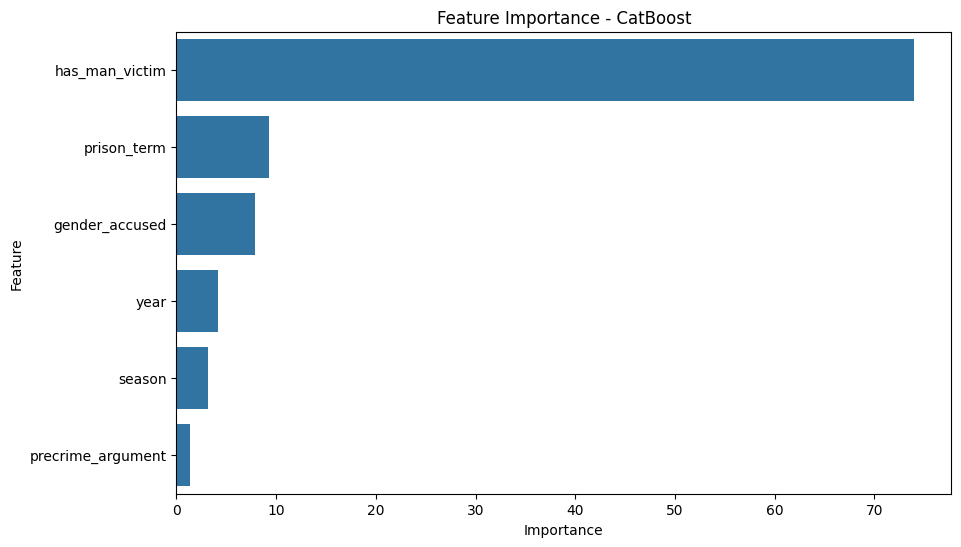

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features2, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [85]:
dump(catboost_model, 'catboost_has_woman_victim_model.joblib')

['catboost_has_woman_victim_model.joblib']

RandomForest

In [27]:
print("Inf:", np.isinf(df['prison_term']).sum())
print("Большие значения (>1e308):", (df['prison_term'].abs() > 1e308).sum())

Inf: 11
Большие значения (>1e308): 11


In [28]:
def clean_prison_term(df, column='prison_term'):
    df[column] = df[column].replace([np.inf, -np.inf], np.nan)
    df[column] = df[column].clip(upper=1e308, lower=-1e308)
    return df

df = clean_prison_term(df.copy(), 'prison_term')

X_train['prison_term'] = df.loc[X_train.index, 'prison_term']
X_val['prison_term'] = df.loc[X_val.index, 'prison_term']
X_test['prison_term'] = df.loc[X_test.index, 'prison_term']

In [29]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [30]:
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()

year
2016          6090
2017          5894
2018          4935
2020          4446
2021          4293
2019          4172
2022          4031
2023          2380
другое год    1328
Name: count, dtype: int64

In [31]:
X_train['judge'] = df.loc[X_train.index, 'judge']
X_val['judge'] = df.loc[X_val.index, 'judge']
X_test['judge'] = df.loc[X_test.index, 'judge']

X_train['region_name'] = df.loc[X_train.index, 'region_name']
X_val['region_name'] = df.loc[X_val.index, 'region_name']
X_test['region_name'] = df.loc[X_test.index, 'region_name']

X_train['year'] = df.loc[X_train.index, 'year']
X_val['year'] = df.loc[X_val.index, 'year']
X_test['year'] = df.loc[X_test.index, 'year']

In [35]:
target = 'has_woman_victim'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name', 'season']
other_features = [
    'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
    'has_man_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',  
    'физическое воздействие', 'холодное оружие', 'тяжелые предметы',
    'огнестрельное оружие','удушение', 'другое',
    'личная неприязнь', 'ревность', 'корысть', 'алкоголь/наркотики',
    'аморальность', 'насилие', 'другой мотив', 
    'жилое помещение', 'уличное пространство', 'общественный транспорт',
    'общественное место', 'подъезд и прилегающие зоны', 'рабочая зона', 'другое место', 
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 35), (7514, 35), (7514, 35))

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaling', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Заменяем NaN на медиану
        ('scaler', StandardScaler())
    ]), numeric_features),
])

X_train2 = column_transformer.fit_transform(X_train)
X_val2 = column_transformer.transform(X_val)
X_test2 = column_transformer.transform(X_test)
feature_names2 = column_transformer.get_feature_names_out()

In [ ]:
# column_transformer = ColumnTransformer([
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
#     ('scaling', StandardScaler(), numeric_features),
# ])

In [235]:
# def plot_feature_importance(model, feature_names, model_name):
#     importance = model.feature_importances_
#     feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
#     feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
#     # plt.figure(figsize=(10, 6))
#     # sns.barplot(x='Importance', y='Feature', data=feature_importance)
#     # plt.title(f'Feature Importance - {model_name}')
    
#     return feature_importance

# rf_model = RandomForestClassifier(
#     n_estimators=1000,  
#     max_depth=6,      
#     random_state=42,   
#     verbose=1,         
#     n_jobs=-1          
# )

# rf_model.fit(X_train2, y_train)

# y_pred_rf = rf_model.predict(X_test2)

# rf_accuracy = accuracy_score(y_test, y_pred_rf)

# rf_report = classification_report(y_test, y_pred_rf)

# rf_importance = plot_feature_importance(rf_model, feature_names2, 'RandomForest')

# print("RandomForest Results:")
# print(f"Accuracy: {rf_accuracy:.4f}")
# print("\nClassification Report:")
# print(rf_report)
# print("\nFeature Importance:")
# print(rf_importance)

[I 2025-04-30 00:48:23,434] A new study created in memory with name: no-name-6a96dc2c-b766-486d-a871-b0fe8e611e0c
[I 2025-04-30 00:48:24,133] Trial 0 finished with value: 0.572933898688088 and parameters: {'n_estimators': 574, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.572933898688088.
[I 2025-04-30 00:48:25,377] Trial 1 finished with value: 0.5858188681468245 and parameters: {'n_estimators': 886, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.5858188681468245.
[I 2025-04-30 00:48:27,747] Trial 2 finished with value: 0.6111309914845895 and parameters: {'n_estimators': 507, 'max_depth': 29, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': False}. Best is trial 2 with value: 0.6111309914845895.
[I 2025-04-30 00:48:29,548] Trial 3 finished with value: 0.6121383800891396 

Best RandomForest Params:
{'n_estimators': 452, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True}

RandomForest Results:
Accuracy: 0.6831
Precision: 0.6395
Recall: 0.6831
F1: 0.6124

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80      5115
           1       0.51      0.13      0.21      2399

    accuracy                           0.68      7514
   macro avg       0.61      0.54      0.51      7514
weighted avg       0.64      0.68      0.61      7514


Feature Importance:
                                              Feature  Importance
34                               scaling__prison_term    0.567289
29                    ohe__region_name_другое регионы    0.040429
30                                  ohe__season_Весна    0.036094
31                                   ohe__season_Зима    0.034767
33                                  ohe__season_Осень    0.03

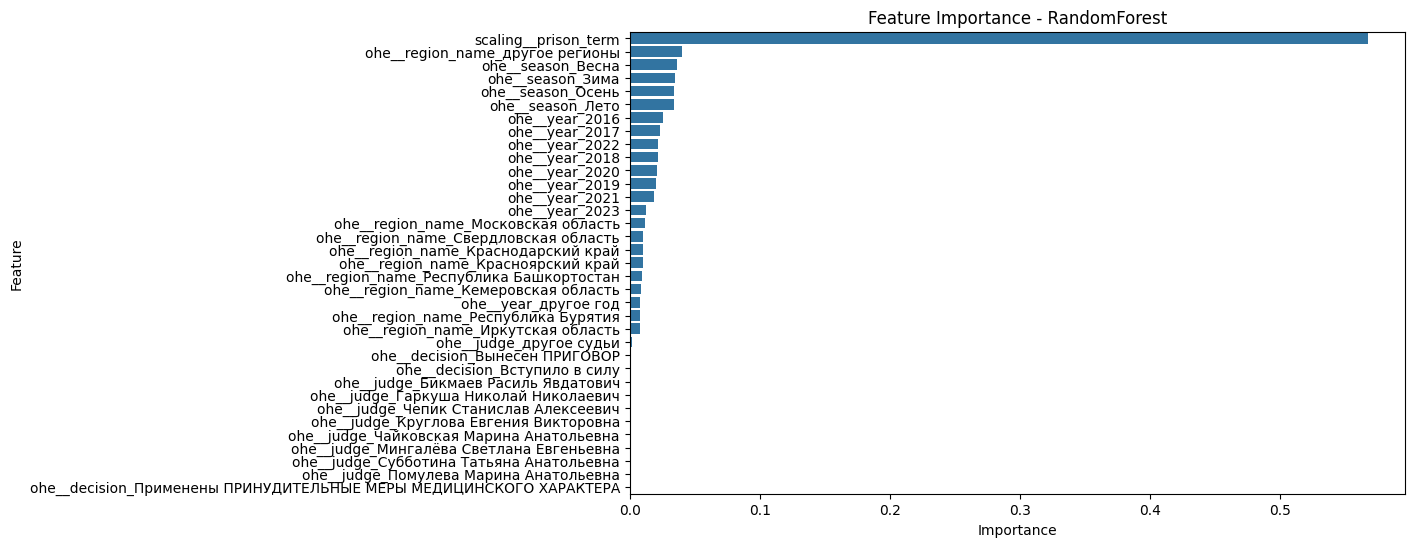

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_random_forest_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': 0
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1 

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best RandomForest Params:")
    print(best_params)

    # final_params = {
    #     'n_estimators': best_params['n_estimators'],
    #     'max_depth': best_params['max_depth'],
    #     'min_samples_split': best_params['min_samples_split'],
    #     'min_samples_leaf': best_params['min_samples_leaf'],
    #     'max_features': best_params['max_features'],
    #     'bootstrap': best_params['bootstrap'],
    #     'random_state': 42,
    #     'n_jobs': -1,
    #     'verbose': 1
    # }
    
    final_model = RandomForestClassifier(**best_params)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )

    y_pred_rf = final_model.predict(X_test)

    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="weighted", zero_division=0)
    rf_report = classification_report(y_test, y_pred_rf)

    rf_importance = plot_feature_importance(final_model, feature_names, 'RandomForest')

    print("\nRandomForest Results:")
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(rf_report)
    print("\nFeature Importance:")
    print(rf_importance)

    return final_model, rf_importance

rf_model, rf_importance = train_random_forest_with_optuna(
    X_train2, y_train, X_val2, y_val, X_test2, y_test, feature_names2
)

тоже самое, но для жертвы мужского пола 

In [86]:
target = 'has_man_victim'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name', 'season']
other_features = [
    'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',  
    'физическое воздействие', 'холодное оружие', 'тяжелые предметы',
    'огнестрельное оружие','удушение', 'другое',
    'личная неприязнь', 'ревность', 'корысть', 'алкоголь/наркотики',
    'аморальность', 'насилие', 'другой мотив', 
    'жилое помещение', 'уличное пространство', 'общественный транспорт',
    'общественное место', 'подъезд и прилегающие зоны', 'рабочая зона', 'другое место', 
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 35), (7514, 35), (7514, 35))

[I 2025-04-30 02:53:28,275] A new study created in memory with name: no-name-68224f83-b35a-41b1-8c8b-4494afe028a0
[I 2025-04-30 02:53:32,317] Trial 0 finished with value: 0.9000792928547857 and parameters: {'iterations': 619, 'learning_rate': 0.016376212086524913, 'depth': 4, 'l2_leaf_reg': 9.246290736084953, 'bagging_temperature': 0.28991122578118156}. Best is trial 0 with value: 0.9000792928547857.
[I 2025-04-30 02:53:33,833] Trial 1 finished with value: 0.8985327493792153 and parameters: {'iterations': 236, 'learning_rate': 0.11714148142617849, 'depth': 4, 'l2_leaf_reg': 9.483976548666858, 'bagging_temperature': 0.6156466496543882}. Best is trial 0 with value: 0.9000792928547857.
[I 2025-04-30 02:53:35,865] Trial 2 finished with value: 0.8987557855390766 and parameters: {'iterations': 907, 'learning_rate': 0.12347352819449203, 'depth': 5, 'l2_leaf_reg': 5.158208968083045, 'bagging_temperature': 0.04999377198157895}. Best is trial 0 with value: 0.9000792928547857.
[I 2025-04-30 02:53

Best CatBoost Params:
{'iterations': 406, 'learning_rate': 0.03640658896446604, 'depth': 7, 'l2_leaf_reg': 2.816099967571444, 'bagging_temperature': 0.9862554283499432}
0:	learn: 0.6336607	total: 11.2ms	remaining: 4.55s
100:	learn: 0.2134818	total: 1.07s	remaining: 3.24s
200:	learn: 0.2089460	total: 2.07s	remaining: 2.11s
300:	learn: 0.2056985	total: 3.09s	remaining: 1.08s
400:	learn: 0.2015936	total: 4.25s	remaining: 53ms
405:	learn: 0.2014723	total: 4.3s	remaining: 0us

CatBoost Results:
Accuracy: 0.8954
Precision: 0.9143
Recall: 0.8954
F1: 0.9002

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.91      0.79      1586
           1       0.97      0.89      0.93      5928

    accuracy                           0.90      7514
   macro avg       0.83      0.90      0.86      7514
weighted avg       0.91      0.90      0.90      7514


Feature Importance:
                       Feature  Importance
9             has_woman_victi

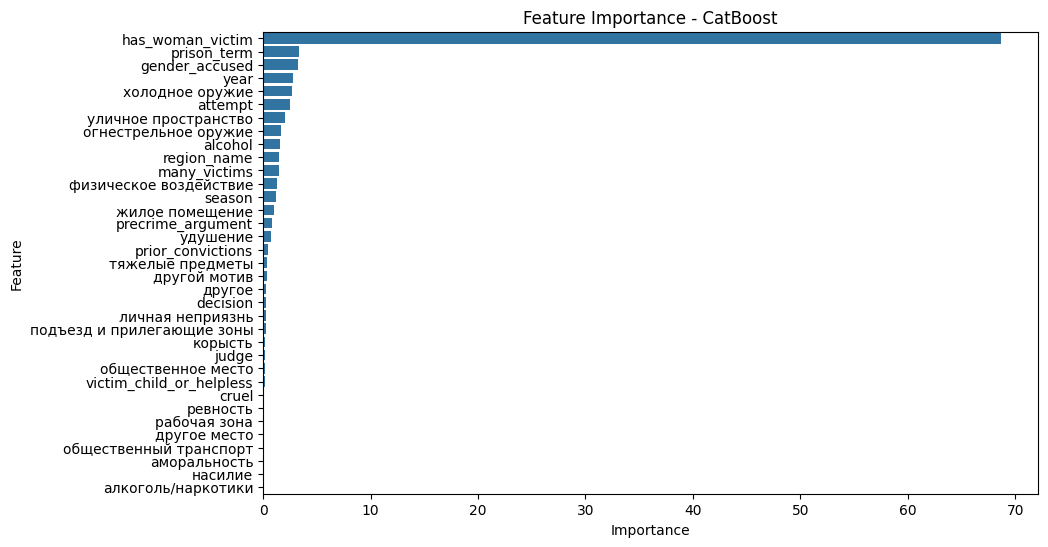

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [101]:
target = 'has_man_victim'

numeric_features = ['prison_term']
categorical_features = ['year', 'season']
other_features = [
    'gender_accused', 'alcohol',
    'has_woman_victim', 'attempt',
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 7), (7514, 7), (7514, 7))

[I 2025-04-30 03:29:05,788] A new study created in memory with name: no-name-5e6c1e0c-9ee9-41bb-8915-e7dc8af896c1
[I 2025-04-30 03:29:08,104] Trial 0 finished with value: 0.8907781484769209 and parameters: {'iterations': 643, 'learning_rate': 0.028170192391656575, 'depth': 4, 'l2_leaf_reg': 3.8173723500553143, 'bagging_temperature': 0.9748087871746511}. Best is trial 0 with value: 0.8907781484769209.
[I 2025-04-30 03:29:08,984] Trial 1 finished with value: 0.8910151050000984 and parameters: {'iterations': 544, 'learning_rate': 0.14709153168395644, 'depth': 7, 'l2_leaf_reg': 5.567380567354584, 'bagging_temperature': 0.3903160223717639}. Best is trial 1 with value: 0.8910151050000984.
[I 2025-04-30 03:29:10,581] Trial 2 finished with value: 0.8912112667162424 and parameters: {'iterations': 642, 'learning_rate': 0.05141728212244995, 'depth': 7, 'l2_leaf_reg': 7.445275207182911, 'bagging_temperature': 0.6722584287977915}. Best is trial 2 with value: 0.8912112667162424.
[I 2025-04-30 03:29:

Best CatBoost Params:
{'iterations': 331, 'learning_rate': 0.014679939053840739, 'depth': 5, 'l2_leaf_reg': 8.685054882436676, 'bagging_temperature': 0.5959413683681967}
0:	learn: 0.6692065	total: 5.28ms	remaining: 1.74s
100:	learn: 0.2403172	total: 554ms	remaining: 1.26s
200:	learn: 0.2331224	total: 1.11s	remaining: 715ms
300:	learn: 0.2319275	total: 1.66s	remaining: 165ms
330:	learn: 0.2317981	total: 1.81s	remaining: 0us

CatBoost Results:
Accuracy: 0.8838
Precision: 0.9149
Recall: 0.8838
F1: 0.8907

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.95      0.78      1586
           1       0.98      0.87      0.92      5928

    accuracy                           0.88      7514
   macro avg       0.82      0.91      0.85      7514
weighted avg       0.91      0.88      0.89      7514


Feature Importance:
            Feature  Importance
4  has_woman_victim   90.045223
2    gender_accused    3.322052
3           alcohol    2.

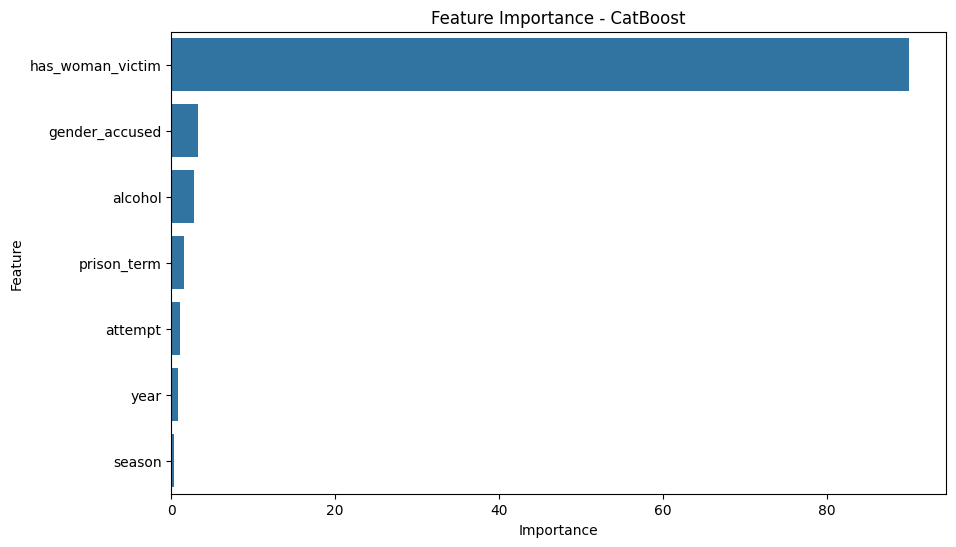

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [103]:
dump(catboost_model, 'catboost_has_man_victim_model.joblib')

['catboost_has_man_victim_model.joblib']

In [96]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaling', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Заменяем NaN на медиану
        ('scaler', StandardScaler())
    ]), numeric_features),
])

X_train2 = column_transformer.fit_transform(X_train)
X_val2 = column_transformer.transform(X_val)
X_test2 = column_transformer.transform(X_test)
feature_names2 = column_transformer.get_feature_names_out()

[I 2025-04-30 03:25:19,435] A new study created in memory with name: no-name-dad9c952-a878-4e90-8d59-480d30f2c455
[I 2025-04-30 03:25:19,717] Trial 0 finished with value: 0.7026455558939382 and parameters: {'n_estimators': 103, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.7026455558939382.
[I 2025-04-30 03:25:20,611] Trial 1 finished with value: 0.6959489635841527 and parameters: {'n_estimators': 491, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.7026455558939382.
[I 2025-04-30 03:25:21,416] Trial 2 finished with value: 0.7024261082573716 and parameters: {'n_estimators': 585, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.7026455558939382.
[I 2025-04-30 03:25:22,012] Trial 3 finished with value: 0.7041930688079169 and 

Best RandomForest Params:
{'n_estimators': 826, 'max_depth': 21, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}

RandomForest Results:
Accuracy: 0.7698
Precision: 0.6733
Recall: 0.7698
F1: 0.7000

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.04      0.07      1586
           1       0.79      0.96      0.87      5928

    accuracy                           0.77      7514
   macro avg       0.51      0.50      0.47      7514
weighted avg       0.67      0.77      0.70      7514


Feature Importance:
                 Feature  Importance
13  scaling__prison_term    0.949845
12     ohe__season_Осень    0.005384
11      ohe__season_Лето    0.004894
10      ohe__season_Зима    0.004641
9      ohe__season_Весна    0.004291
1         ohe__year_2017    0.004041
3         ohe__year_2019    0.003948
0         ohe__year_2016    0.003569
4         ohe__year_2020    0.003568
2         ohe__ye

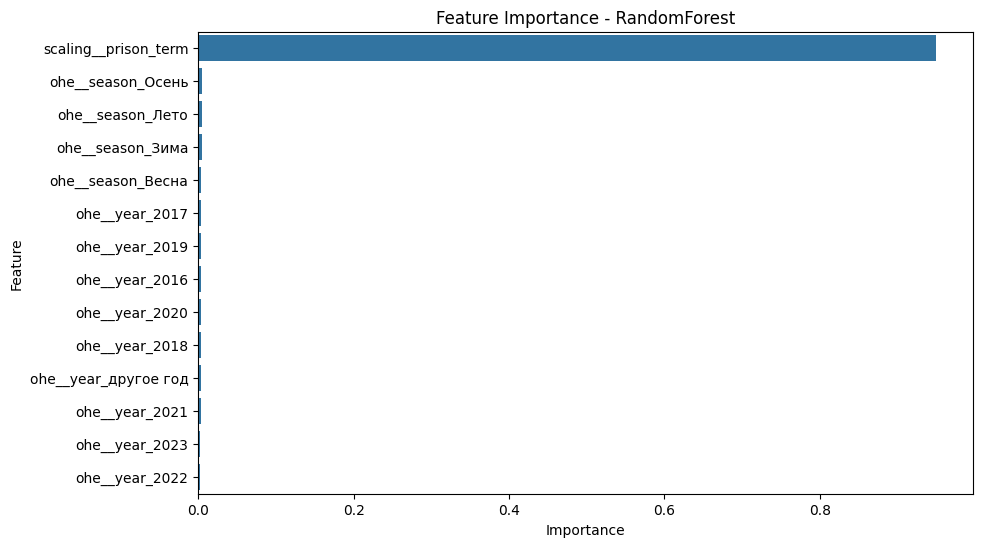

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_random_forest_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': 0
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1 

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best RandomForest Params:")
    print(best_params)

    # final_params = {
    #     'n_estimators': best_params['n_estimators'],
    #     'max_depth': best_params['max_depth'],
    #     'min_samples_split': best_params['min_samples_split'],
    #     'min_samples_leaf': best_params['min_samples_leaf'],
    #     'max_features': best_params['max_features'],
    #     'bootstrap': best_params['bootstrap'],
    #     'random_state': 42,
    #     'n_jobs': -1,
    #     'verbose': 1
    # }
    
    final_model = RandomForestClassifier(**best_params)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )

    y_pred_rf = final_model.predict(X_test)

    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="weighted", zero_division=0)
    rf_report = classification_report(y_test, y_pred_rf)

    rf_importance = plot_feature_importance(final_model, feature_names, 'RandomForest')

    print("\nRandomForest Results:")
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(rf_report)
    print("\nFeature Importance:")
    print(rf_importance)

    return final_model, rf_importance

rf_model, rf_importance = train_random_forest_with_optuna(
    X_train2, y_train, X_val2, y_val, X_test2, y_test, feature_names2
)

In [98]:
target = 'has_man_victim'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name', 'season']
other_features = [
    'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',  
    'физическое воздействие', 'холодное оружие', 'тяжелые предметы',
    'огнестрельное оружие','удушение', 'другое',
    'личная неприязнь', 'ревность', 'корысть', 'алкоголь/наркотики',
    'аморальность', 'насилие', 'другой мотив', 
    'жилое помещение', 'уличное пространство', 'общественный транспорт',
    'общественное место', 'подъезд и прилегающие зоны', 'рабочая зона', 'другое место', 
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 35), (7514, 35), (7514, 35))

In [99]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaling', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Заменяем NaN на медиану
        ('scaler', StandardScaler())
    ]), numeric_features),
])

X_train2 = column_transformer.fit_transform(X_train)
X_val2 = column_transformer.transform(X_val)
X_test2 = column_transformer.transform(X_test)
feature_names2 = column_transformer.get_feature_names_out()

[I 2025-04-30 03:26:41,061] A new study created in memory with name: no-name-b5e8bd62-ebe9-4927-b7e7-d93bc8679aed
[I 2025-04-30 03:26:41,936] Trial 0 finished with value: 0.6960260705840853 and parameters: {'n_estimators': 888, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.6960260705840853.
[I 2025-04-30 03:26:42,691] Trial 1 finished with value: 0.6960260705840853 and parameters: {'n_estimators': 635, 'max_depth': 25, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.6960260705840853.
[I 2025-04-30 03:26:43,552] Trial 2 finished with value: 0.7019004414982104 and parameters: {'n_estimators': 498, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.7019004414982104.
[I 2025-04-30 03:26:43,985] Trial 3 finished with value: 0.6960260705840853

Best RandomForest Params:
{'n_estimators': 118, 'max_depth': 16, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': False}

RandomForest Results:
Accuracy: 0.7720
Precision: 0.6801
Recall: 0.7720
F1: 0.7027

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.05      0.08      1586
           1       0.79      0.97      0.87      5928

    accuracy                           0.77      7514
   macro avg       0.53      0.51      0.47      7514
weighted avg       0.68      0.77      0.70      7514


Feature Importance:
                                              Feature  Importance
34                               scaling__prison_term    0.528818
31                                   ohe__season_Зима    0.035772
33                                  ohe__season_Осень    0.033598
29                    ohe__region_name_другое регионы    0.033175
13                                     ohe__year_2017    0.

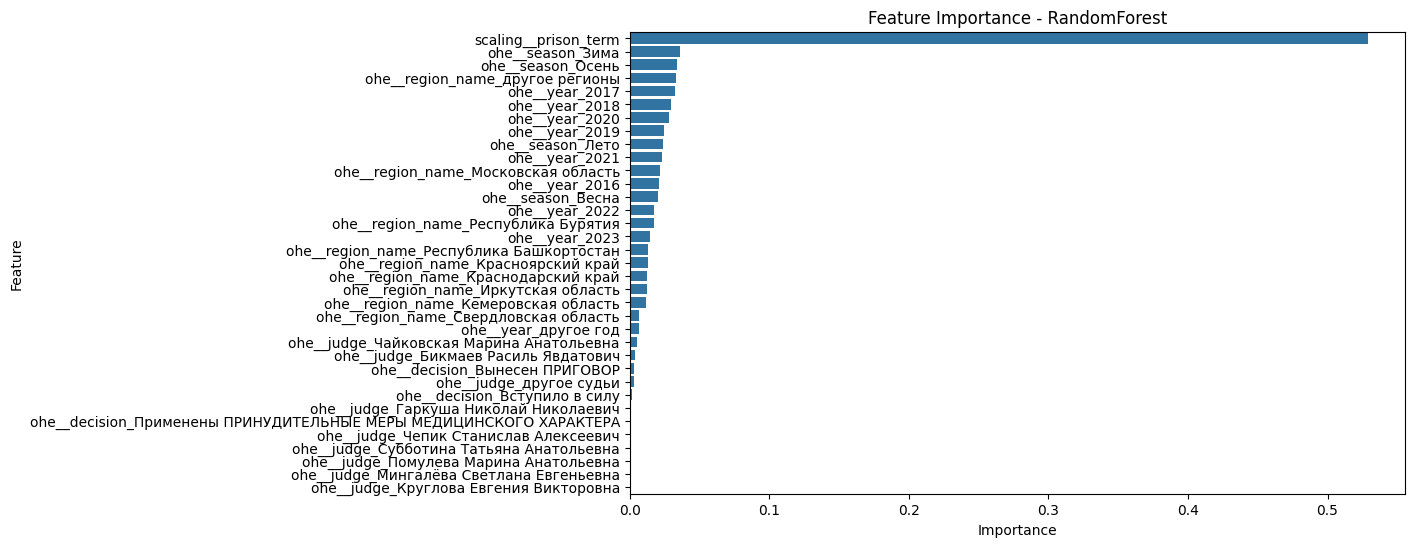

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_random_forest_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': 0
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1 

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best RandomForest Params:")
    print(best_params)

    # final_params = {
    #     'n_estimators': best_params['n_estimators'],
    #     'max_depth': best_params['max_depth'],
    #     'min_samples_split': best_params['min_samples_split'],
    #     'min_samples_leaf': best_params['min_samples_leaf'],
    #     'max_features': best_params['max_features'],
    #     'bootstrap': best_params['bootstrap'],
    #     'random_state': 42,
    #     'n_jobs': -1,
    #     'verbose': 1
    # }
    
    final_model = RandomForestClassifier(**best_params)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )

    y_pred_rf = final_model.predict(X_test)

    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="weighted", zero_division=0)
    rf_report = classification_report(y_test, y_pred_rf)

    rf_importance = plot_feature_importance(final_model, feature_names, 'RandomForest')

    print("\nRandomForest Results:")
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(rf_report)
    print("\nFeature Importance:")
    print(rf_importance)

    return final_model, rf_importance

rf_model, rf_importance = train_random_forest_with_optuna(
    X_train2, y_train, X_val2, y_val, X_test2, y_test, feature_names2
)